In [19]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
DATA_DIR = "../data/color"

import os
print(os.getcwd())

E:\Github Repos Working\plant disease detector\notebooks


In [20]:
classes = sorted(os.listdir(DATA_DIR))
num_classes = len(classes)

count = {}
for cls in classes:
    cls_path = os.path.join(DATA_DIR, cls)
    count[cls] = len(os.listdir(cls_path))


total_imgs = sum(count.values())

In [21]:
print("Total classes:", num_classes)
print("Total images:", total_imgs)
print("Max class:", max(count, key=count.get), count[max(count, key=count.get)])
print("Min class:", min(count, key=count.get), count[min(count, key=count.get)])

Total classes: 38
Total images: 54305
Max class: Orange___Haunglongbing_(Citrus_greening) 5507
Min class: Potato___healthy 152


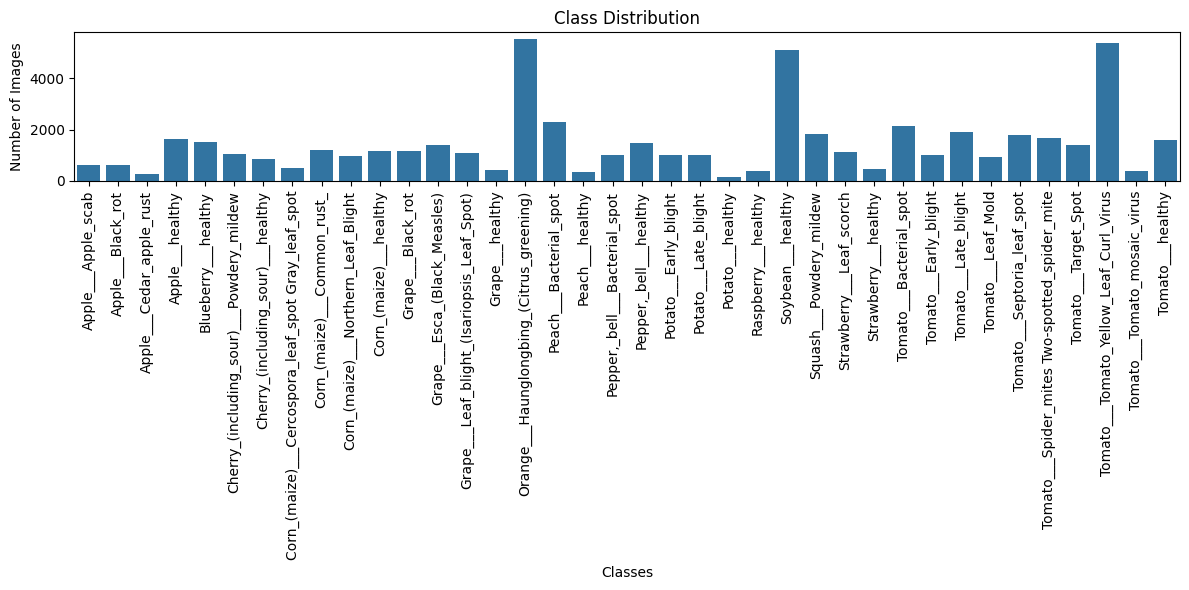

In [22]:
plt.figure(figsize=(12,6))
sns.barplot(x=list(count.keys()), y=list(count.values()))
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.xlabel("Classes")
plt.tight_layout()
plt.show()

In [ ]:
def show_sample(class_name, n=5):
    path = os.path.join(DATA_DIR, class_name)
    images = os.listdir(path)
    plt.figure(figsize=(15,3))

    for i in range(n):
        img_path = os.path.join(path,random.choice(images))
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(class_name[:20])
        plt.axis("off")
        plt.tight_layout()

    plt.show()
print()

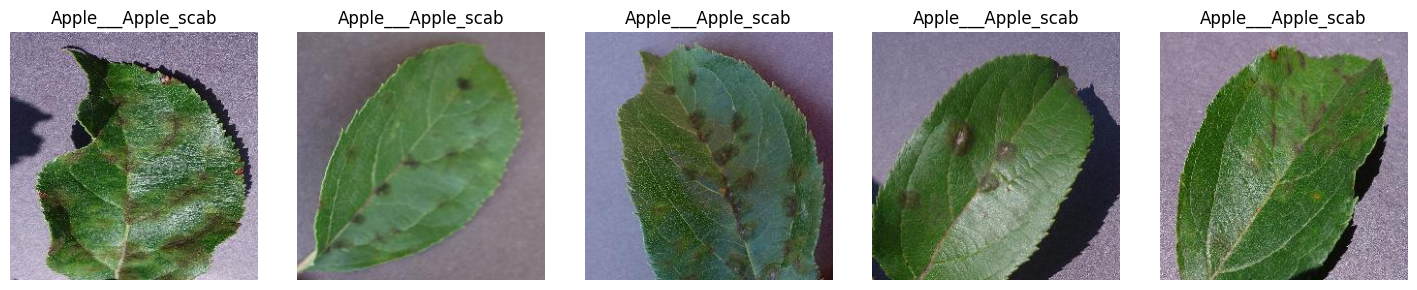

In [24]:
show_sample(classes[0])

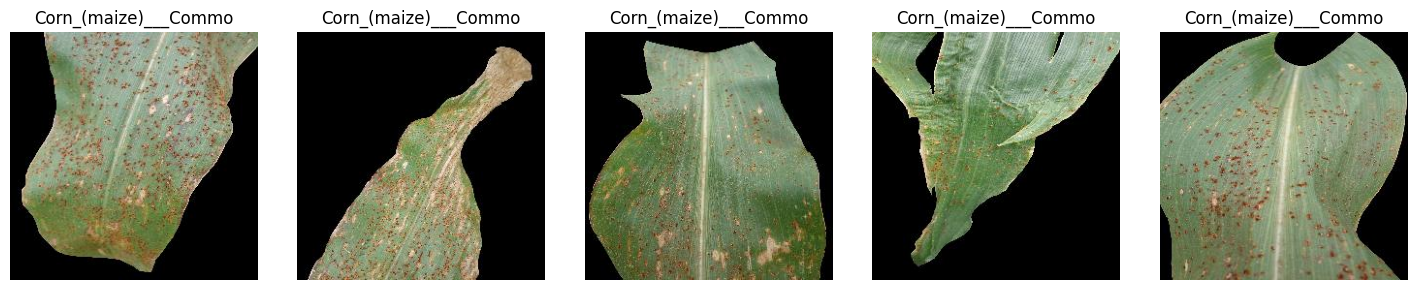

In [25]:
show_sample(classes[8])

In [27]:
shapes = []

for cls in classes:
    path = os.path.join(DATA_DIR, cls)
    for img_name in os.listdir(path)[:100]:  # sample 50 per class (faster)
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            shapes.append(img.shape)

# Unique shapes
unique_shapes = set(shapes)
print("Unique image shapes:", unique_shapes)

Unique image shapes: {(256, 256, 3)}


In [39]:
means = []
stds = []

for cls in classes:
    path = os.path.join(DATA_DIR, cls)
    for img_name in os.listdir(path)[:500]:
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            img = img/255
            means.append(np.mean(img))
            stds.append(np.std(img))


In [30]:
plt.figure(figsize=(12,6))
sns.barplot(x=list(count.keys()), y=list(count.values()))
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.tight_layout()

plt.savefig("../plots/class_distribution.png")
plt.close()
print("saved")

In [32]:
print("Overall Mean:", np.mean(means))
print("Overall Std:", np.mean(stds))

Overall Mean: 0.462381572506707
Overall Std: 0.1842278331685266


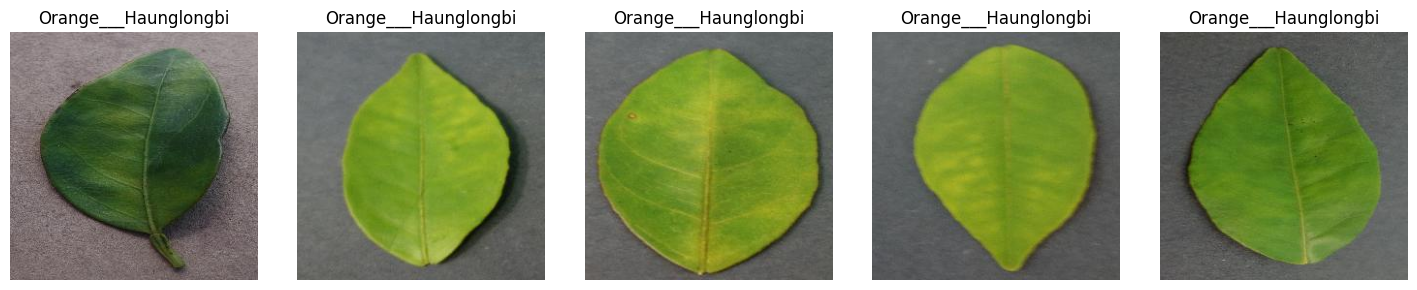

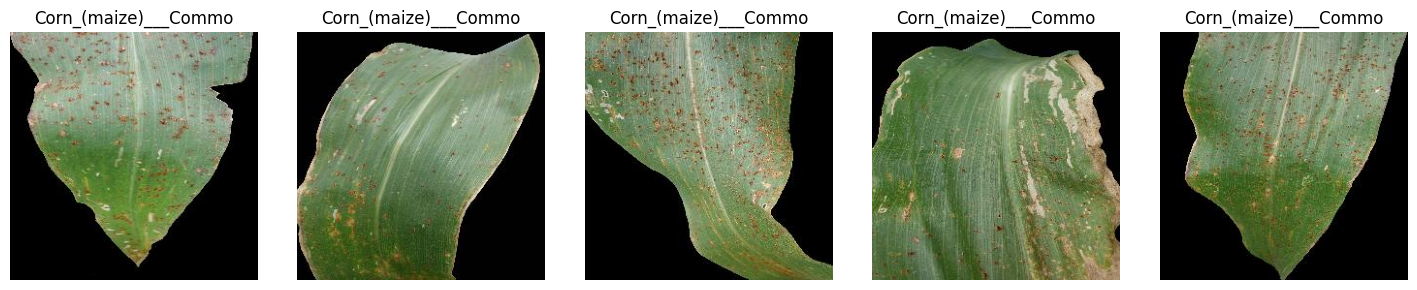

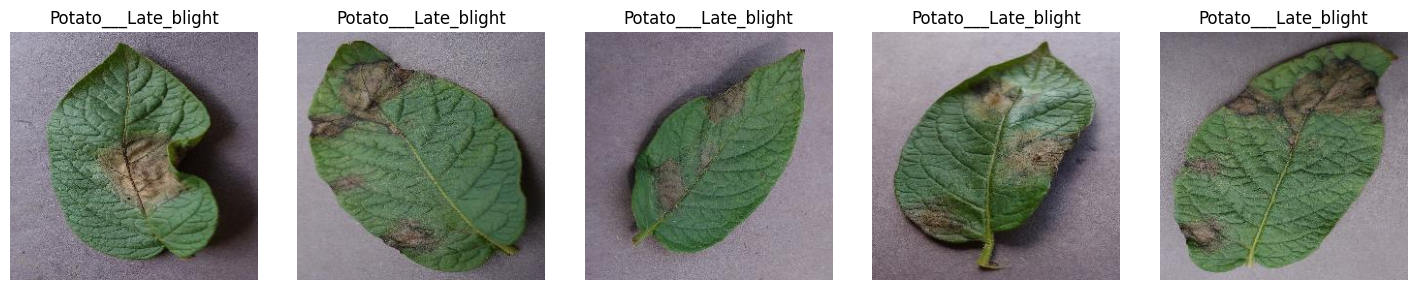

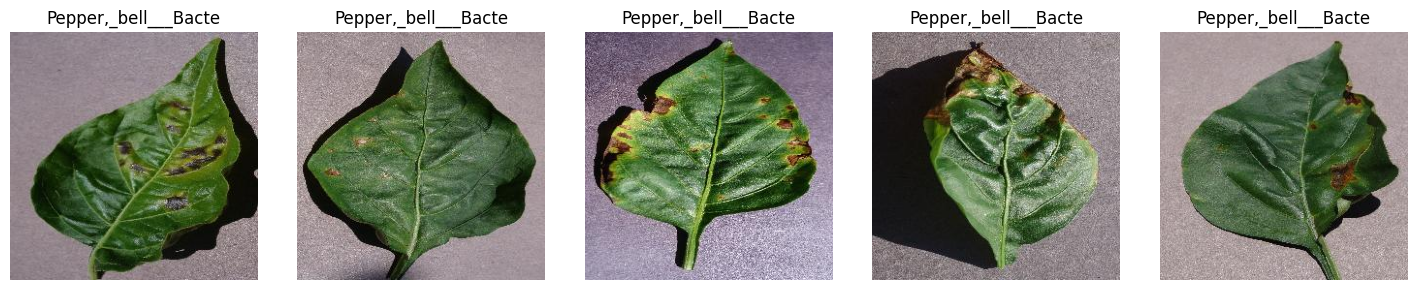

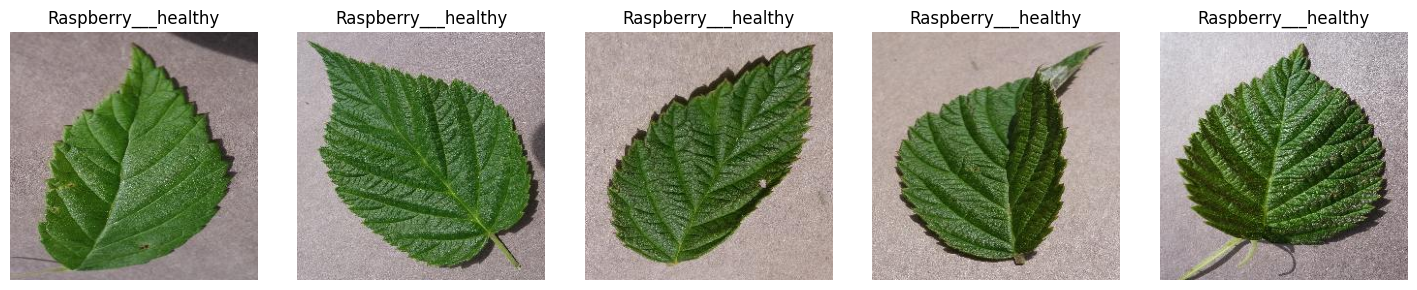

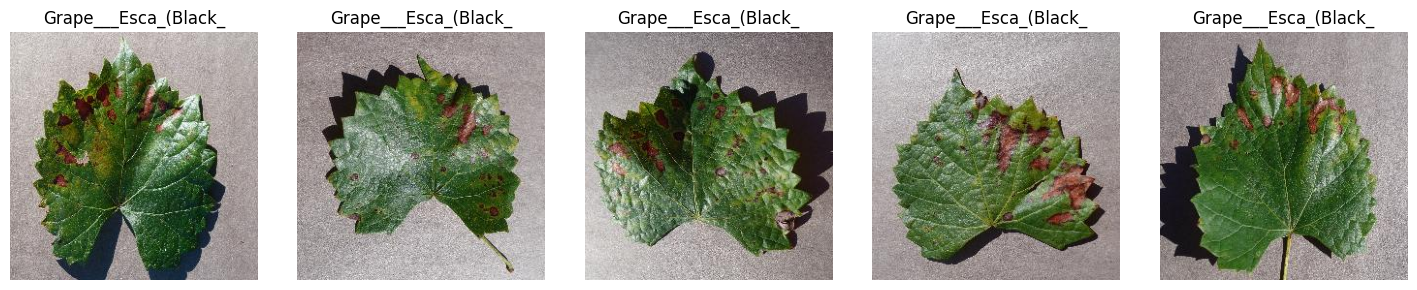

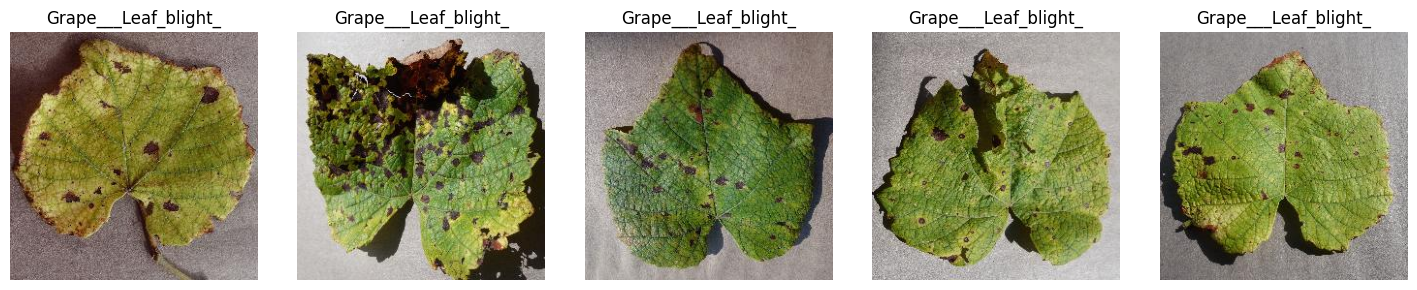

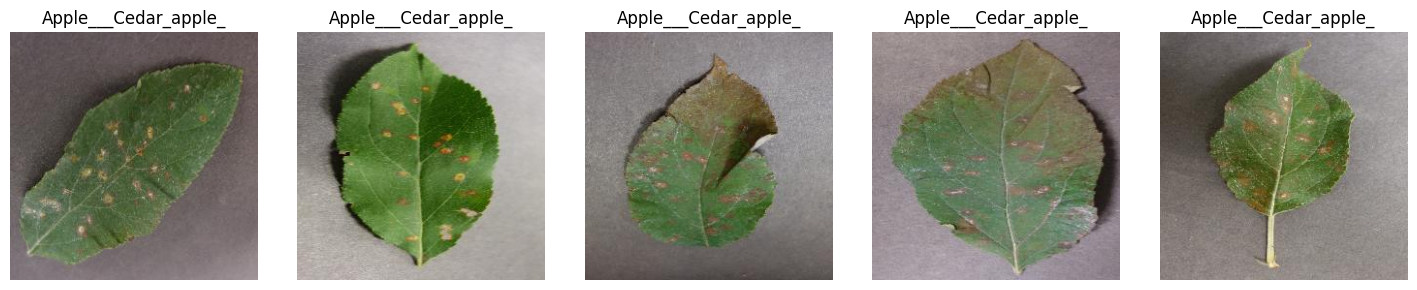

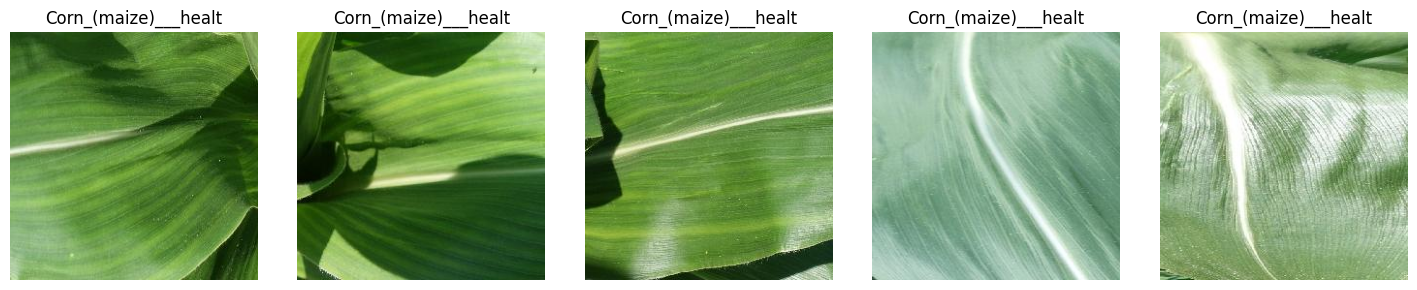

In [36]:
for cls in random.sample(classes, 9):
    show_sample(cls)

In [33]:
corrupt = 0

for cls in classes:
    path = os.path.join(DATA_DIR, cls)
    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path)
        if img is None:
            corrupt += 1

print("Corrupt images:", corrupt)

Corrupt images: 0


In [38]:
max_class = max(count.values())
min_class = min(count.values())

print("Imbalance Ratio:", max_class / min_class)

Imbalance Ratio: 36.23026315789474
